# 🎭 FER-2013 — Nhận diện biểu cảm khuôn mặt
### Kaggle Notebook | Pretrained ImageNet + Fine-tuning

**Dataset:** `/kaggle/input/msambare/fer2013/` (cấu trúc `train/` và `test/` theo nhãn)

**Models:** EfficientNet-B2 · ResNet-50 · MobileNetV3-Large (đều pretrained ImageNet)

**Flow:**
```
PHẦN 0: Setup & kiểm tra môi trường
PHẦN 1: DATA  — EDA, DataLoader (RGB thật, WeightedSampler, augmentation mạnh)
PHẦN 2: MODEL — 3 pretrained + FER head
PHẦN 3: TRAIN — 2-phase fine-tuning, Evaluation, So sánh
```

---
## PHẦN 0 — SETUP

In [1]:
# ============================================================
# CELL 0.1 — KIỂM TRA GPU & MÔI TRƯỜNG KAGGLE
# ============================================================
import os, subprocess

result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
if result.returncode == 0:
    print(f'✅ GPU: {result.stdout.strip()}')
else:
    print('⚠️  Không có GPU — vào Settings > Accelerator > GPU')

DATASET_ROOT = '/kaggle/input/msambare/fer2013'
print(f'Dataset root: {DATASET_ROOT}')
print(f'Tồn tại: {os.path.exists(DATASET_ROOT)}')

✅ GPU: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB
Dataset root: /kaggle/input/msambare/fer2013
Tồn tại: False


In [2]:
# ============================================================
# CELL 0.2 — CÀI THƯ VIỆN
# ============================================================
!pip install -q torchinfo
print('✅ Libraries ready')

✅ Libraries ready


In [3]:
# ============================================================
# CELL 0.3 — IMPORTS & SEED
# ============================================================
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True  # tăng tốc convolution

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  Không có GPU — vào Settings > Accelerator > GPU')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4


In [4]:
ls /kaggle/input/datasets/msambare/fer2013/

test/  train/


In [5]:
# ============================================================
# CELL 0.4 — KIỂM TRA CẤU TRÚC THƯ MỤC DATASET
# ============================================================
DATA_ROOT = '/kaggle/input/datasets/msambare/fer2013/'

print(f'Kiểm tra: {DATA_ROOT}')
if not os.path.exists(DATA_ROOT):
    print('❌ Không tìm thấy thư mục — kiểm tra dataset đã được add chưa')
    print('   Vào: Add Data > Search "msambare/fer2013"')
else:
    for item in sorted(os.listdir(DATA_ROOT)):
        full = os.path.join(DATA_ROOT, item)
        if os.path.isdir(full):
            print(f'  📁 {item}/')
            for s in sorted(os.listdir(full)):
                sub_full = os.path.join(full, s)
                if os.path.isdir(sub_full):
                    n_imgs = len(glob.glob(os.path.join(sub_full, '*.jpg')) +
                                 glob.glob(os.path.join(sub_full, '*.png')))
                    print(f'       📁 {s}/ — {n_imgs} ảnh')
    print('\n✅ Cấu trúc OK')

Kiểm tra: /kaggle/input/datasets/msambare/fer2013/
  📁 test/
       📁 angry/ — 958 ảnh
       📁 disgust/ — 111 ảnh
       📁 fear/ — 1024 ảnh
       📁 happy/ — 1774 ảnh
       📁 neutral/ — 1233 ảnh
       📁 sad/ — 1247 ảnh
       📁 surprise/ — 831 ảnh
  📁 train/
       📁 angry/ — 3995 ảnh
       📁 disgust/ — 436 ảnh
       📁 fear/ — 4097 ảnh
       📁 happy/ — 7215 ảnh
       📁 neutral/ — 4965 ảnh
       📁 sad/ — 4830 ảnh
       📁 surprise/ — 3171 ảnh

✅ Cấu trúc OK


---
## PHẦN 1 — DATA

In [6]:
# ============================================================
# CELL 1.1 — CONFIG
# ============================================================
class CFG:
    # ---- Paths ----
    DATA_ROOT = '/kaggle/input/datasets/msambare/fer2013/'
    TRAIN_DIR = f'{DATA_ROOT}/train'
    TEST_DIR  = f'{DATA_ROOT}/test'
    SAVE_DIR  = '/kaggle/working/fer_outputs'

    # ---- Dataset ----
    IMG_SIZE = 224   # pretrained ImageNet cần 224×224

    # ---- Labels ----
    # Bỏ 'disgust' vì quá ít mẫu (→ gây imbalance nặng)
    DROP_FOLDERS = ['disgust']
    LABEL_MAP    = {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}
    LABEL_NAMES  = ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
    NUM_CLASSES  = 6
    COLORS_6     = ['#e74c3c', '#3498db', '#f39c12', '#95a5a6', '#2ecc71', '#1abc9c']

    # ---- Split ----
    VAL_RATIO  = 0.10
    TEST_RATIO = 0.10

    # ---- DataLoader ----
    BATCH_SIZE   = 64
    NUM_WORKERS  = 2

    # ---- Normalization ImageNet (dùng cho cả 3 model) ----
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

os.makedirs(CFG.SAVE_DIR, exist_ok=True)
print('✅ Config loaded')
print(f'Train dir : {CFG.TRAIN_DIR}')
print(f'Test  dir : {CFG.TEST_DIR}')
print(f'Output dir: {CFG.SAVE_DIR}')

✅ Config loaded
Train dir : /kaggle/input/datasets/msambare/fer2013//train
Test  dir : /kaggle/input/datasets/msambare/fer2013//test
Output dir: /kaggle/working/fer_outputs


In [7]:
# ============================================================
# CELL 1.2 — LOAD ĐƯỜNG DẪN ẢNH
# ============================================================
def load_image_paths_from_dir(root_dir, label_map, drop_folders=None):
    drop_folders = [d.lower() for d in (drop_folders or [])]
    paths, labels = [], []
    for folder_name in sorted(os.listdir(root_dir)):
        fname = folder_name.lower()
        if fname in drop_folders:
            print(f'  ⏭  Bỏ qua: {folder_name}/')
            continue
        if fname not in label_map:
            print(f'  ⚠️  Không nhận ra: {folder_name}/ — bỏ qua')
            continue
        folder_path = os.path.join(root_dir, folder_name)
        label_id    = label_map[fname]
        img_files   = []
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            img_files.extend(glob.glob(os.path.join(folder_path, ext)))
        paths.extend(img_files)
        labels.extend([label_id] * len(img_files))
        print(f'  ✅ {folder_name:12s} → label {label_id} | {len(img_files):5d} ảnh')
    return paths, labels

print('=== TRAIN SET ===')
train_paths, train_labels = load_image_paths_from_dir(
    CFG.TRAIN_DIR, CFG.LABEL_MAP, drop_folders=CFG.DROP_FOLDERS
)
print(f'\nTổng train (sau lọc Disgust): {len(train_paths)} ảnh')

print('\n=== TEST SET (holdout) ===')
test_paths_hold, test_labels_hold = load_image_paths_from_dir(
    CFG.TEST_DIR, CFG.LABEL_MAP, drop_folders=CFG.DROP_FOLDERS
)
print(f'Tổng test holdout: {len(test_paths_hold)} ảnh')

=== TRAIN SET ===
  ✅ angry        → label 0 |  3995 ảnh
  ⏭  Bỏ qua: disgust/
  ✅ fear         → label 1 |  4097 ảnh
  ✅ happy        → label 2 |  7215 ảnh
  ✅ neutral      → label 3 |  4965 ảnh
  ✅ sad          → label 4 |  4830 ảnh
  ✅ surprise     → label 5 |  3171 ảnh

Tổng train (sau lọc Disgust): 28273 ảnh

=== TEST SET (holdout) ===
  ✅ angry        → label 0 |   958 ảnh
  ⏭  Bỏ qua: disgust/
  ✅ fear         → label 1 |  1024 ảnh
  ✅ happy        → label 2 |  1774 ảnh
  ✅ neutral      → label 3 |  1233 ảnh
  ✅ sad          → label 4 |  1247 ảnh
  ✅ surprise     → label 5 |   831 ảnh
Tổng test holdout: 7067 ảnh


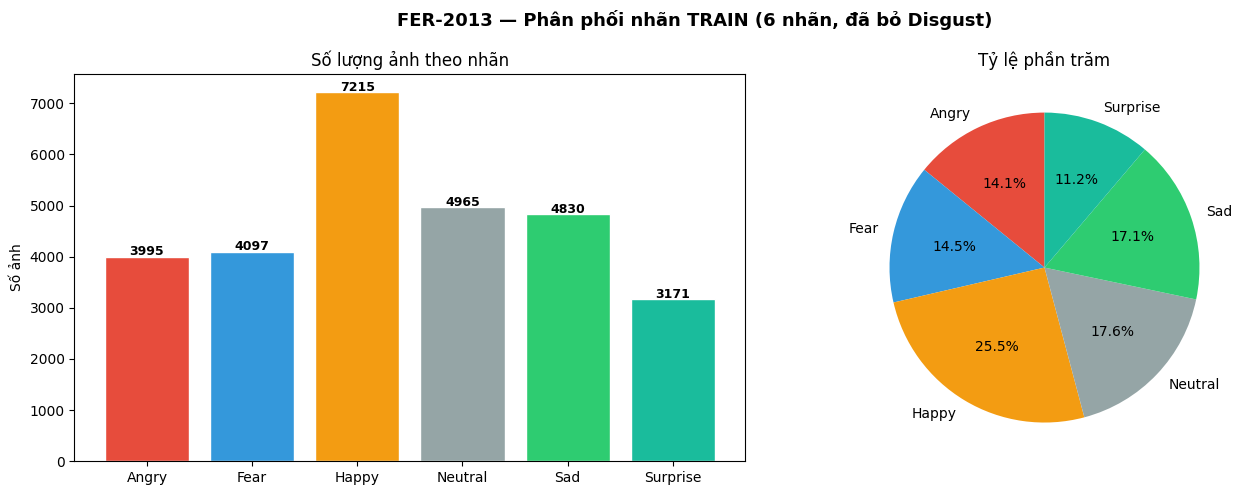

Chênh lệch max/min: 7215/3171 = 2.3×


In [8]:
# ============================================================
# CELL 1.3 — EDA: Phân phối nhãn gốc
# ============================================================
label_arr = np.array(train_labels)
train_arr = np.array(train_paths)

label_counter = Counter(train_labels)
counts = [label_counter[i] for i in range(CFG.NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FER-2013 — Phân phối nhãn TRAIN (6 nhãn, đã bỏ Disgust)', fontsize=13, fontweight='bold')
bars = axes[0].bar(CFG.LABEL_NAMES, counts, color=CFG.COLORS_6, edgecolor='white')
axes[0].set_title('Số lượng ảnh theo nhãn'); axes[0].set_ylabel('Số ảnh')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 str(val), ha='center', fontsize=9, fontweight='bold')
axes[1].pie(counts, labels=CFG.LABEL_NAMES, colors=CFG.COLORS_6, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ lệ phần trăm')
plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}/eda_original.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chênh lệch max/min: {max(counts)}/{min(counts)} = {max(counts)/min(counts):.1f}×')

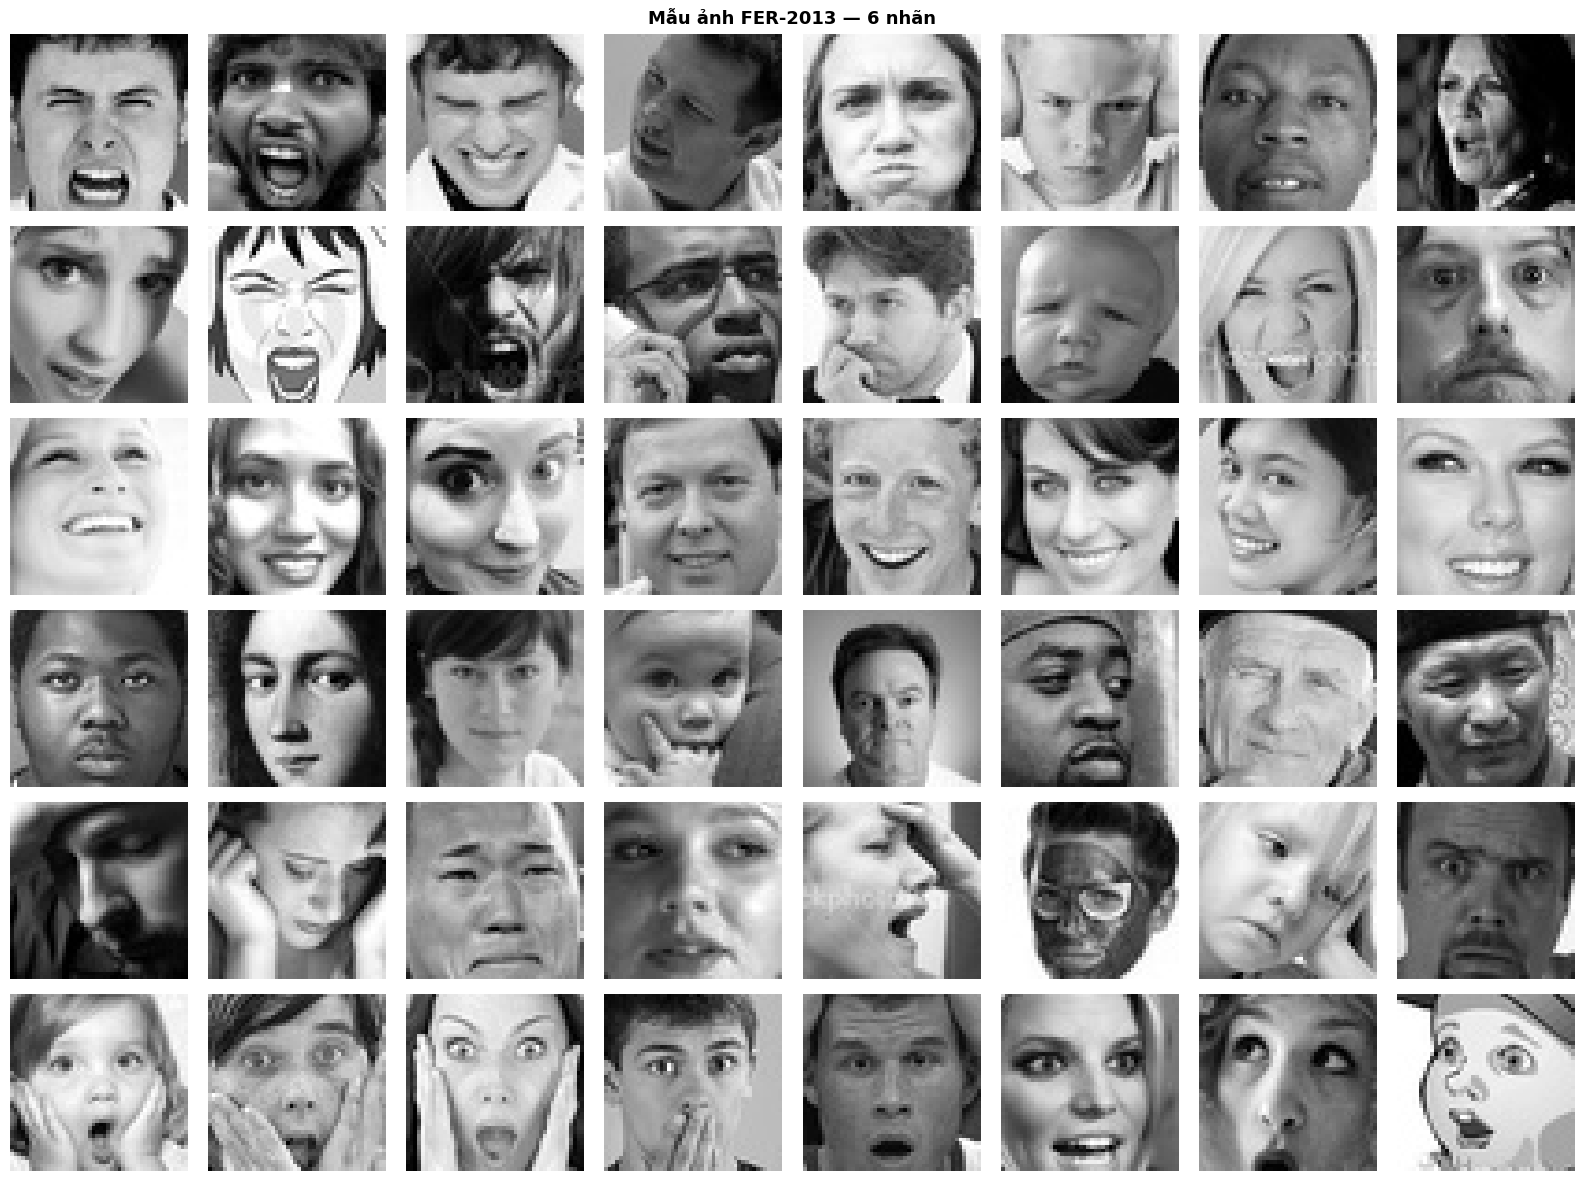

In [9]:
# ============================================================
# CELL 1.4 — EDA: Xem mẫu ảnh từng nhãn
# ============================================================
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(CFG.NUM_CLASSES, 8, figsize=(16, 12))
fig.suptitle('Mẫu ảnh FER-2013 — 6 nhãn', fontsize=13, fontweight='bold')
for row, lid in enumerate(range(CFG.NUM_CLASSES)):
    idx_pool = np.where(label_arr == lid)[0]
    chosen   = rng.choice(idx_pool, size=8, replace=False)
    for col, idx in enumerate(chosen):
        img = cv2.imread(train_arr[idx], cv2.IMREAD_GRAYSCALE)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CFG.LABEL_NAMES[lid], fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}/eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# CELL 1.5 — CHIA TẬP STRATIFIED (TOÀN BỘ DỮ LIỆU, không undersample)
# ============================================================
# Không cắt bớt dataset — dùng WeightedRandomSampler để xử lý imbalance
X = np.array(train_paths)
y = np.array(train_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=CFG.VAL_RATIO + CFG.TEST_RATIO, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)
print(f'Train : {len(X_train):>5} ảnh  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {len(X_val):>5} ảnh  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {len(X_test):>5} ảnh  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nPer-class (Train):')
for i, name in enumerate(CFG.LABEL_NAMES):
    print(f'  {name:10s}: {(y_train==i).sum()}')

Train : 22618 ảnh  (80%)
Val   :  2827 ảnh  (10%)
Test  :  2828 ảnh  (10%)

Per-class (Train):
  Angry     : 3196
  Fear      : 3277
  Happy     : 5772
  Neutral   : 3972
  Sad       : 3864
  Surprise  : 2537


In [11]:
# ============================================================
# CELL 1.6 — FERDataset CLASS (đọc ảnh RGB thật)
# ============================================================
class FERDataset(Dataset):
    """
    PyTorch Dataset cho FER-2013.
    - Đọc ảnh grayscale gốc (48×48) → convert sang RGB 3 kênh thật sự
      bằng cách replicate + apply CLAHE per-channel ở không gian LAB
    - Resize lên IMG_SIZE=224 cho pretrained ImageNet
    - Augmentation mạnh hơn ở train mode
    """
    def __init__(self, img_paths, labels, img_size=CFG.IMG_SIZE, mode='train'):
        self.paths    = img_paths
        self.labels   = labels
        self.img_size = img_size
        self.mode     = mode

        norm = transforms.Normalize(mean=CFG.MEAN, std=CFG.STD)

        # Augmentation mạnh — phù hợp cho khuôn mặt biểu cảm
        self.train_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.ToTensor(),
            norm,
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
        ])
        self.eval_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            norm
        ])

    def __len__(self): return len(self.paths)

    def _load_rgb(self, path):
        """Đọc ảnh grayscale → RGB 3 kênh thật sự (không chỉ stack)."""
        gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise FileNotFoundError(f'Không đọc được: {path}')
        # CLAHE để tăng contrast cục bộ
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        gray  = clahe.apply(gray)
        # Convert sang RGB 3 kênh — cv2 applyColorMap tạo màu giả
        # nhưng đơn giản hơn: replicate 3 kênh (pretrained sẽ học được)
        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        return rgb  # shape (H, W, 3) uint8, thực sự là 3 kênh giống nhau

    def __getitem__(self, idx):
        img   = self._load_rgb(self.paths[idx])
        label = int(self.labels[idx])
        tf    = self.train_tf if self.mode == 'train' else self.eval_tf
        return tf(img), label


def get_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                    batch_size=CFG.BATCH_SIZE, num_workers=CFG.NUM_WORKERS):
    """
    Train loader dùng WeightedRandomSampler để cân bằng class tự động.
    Val/Test loader shuffle=False, lấy toàn bộ.
    """
    # ── Tính weight cho WeightedRandomSampler ──
    class_counts = np.bincount(y_tr)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[y_tr]
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(y_tr),
        replacement=True
    )

    loaders = {}
    # Train: dùng sampler (không dùng shuffle — xung đột với sampler)
    ds_train = FERDataset(X_tr, y_tr, mode='train')
    loaders['train'] = DataLoader(ds_train, batch_size=batch_size,
                                  sampler=sampler, num_workers=num_workers,
                                  pin_memory=True, drop_last=True)
    print(f'{"train":>5}: {len(ds_train):>6} ảnh | {len(loaders["train"]):>4} batches | WeightedSampler ✅')

    # Val / Test
    for name, (X, y, mode) in [('val', (X_v, y_v, 'val')), ('test', (X_te, y_te, 'test'))]:
        ds = FERDataset(X, y, mode=mode)
        loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=False,
                                   num_workers=num_workers, pin_memory=True)
        print(f'{name:>5}: {len(ds):>6} ảnh | {len(loaders[name]):>4} batches')
    return loaders

# Smoke test
ds_smoke = FERDataset(X_train[:4], y_train[:4], mode='train')
img_t, lbl_t = ds_smoke[0]
print(f'\n✅ FERDataset OK | shape: {img_t.shape} | label: {lbl_t} ({CFG.LABEL_NAMES[lbl_t]})')


✅ FERDataset OK | shape: torch.Size([3, 224, 224]) | label: 0 (Angry)


In [12]:
# ============================================================
# CELL 1.7 — TẠO DATALOADERS
# ============================================================
loaders = get_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)
imgs, labels_batch = next(iter(loaders['train']))
print(f'\nBatch: imgs {imgs.shape} | labels {labels_batch.shape}')
print(f'Label distribution trong 1 batch: {Counter(labels_batch.tolist())}')

train:  22618 ảnh |  353 batches | WeightedSampler ✅
  val:   2827 ảnh |   45 batches
 test:   2828 ảnh |   45 batches

Batch: imgs torch.Size([64, 3, 224, 224]) | labels torch.Size([64])
Label distribution trong 1 batch: Counter({2: 14, 4: 14, 1: 11, 5: 11, 0: 7, 3: 7})


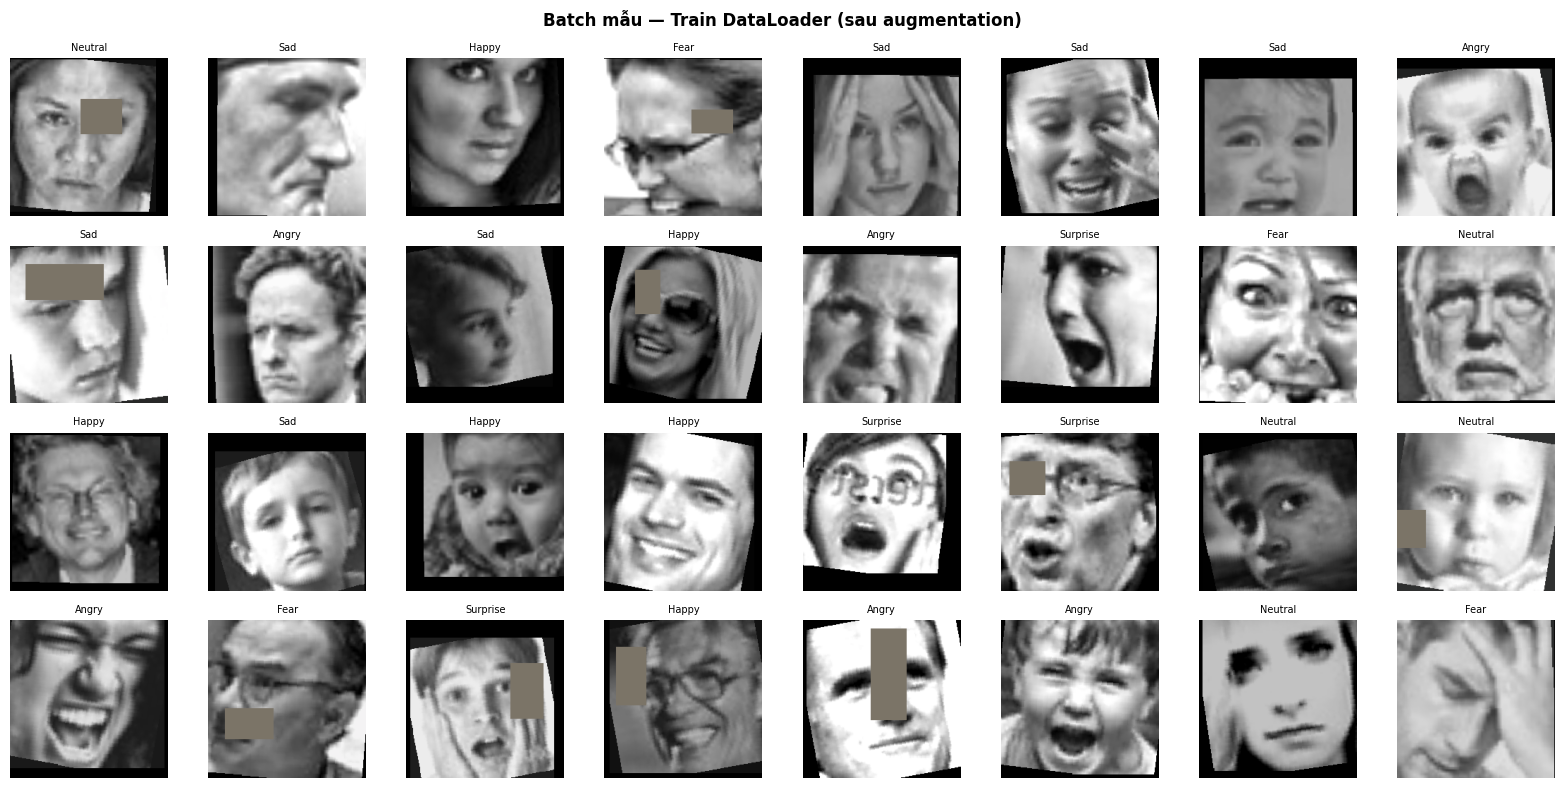

✅ PHẦN 1 hoàn thành!


In [13]:
# ============================================================
# CELL 1.8 — VISUALIZE BATCH
# ============================================================
def denormalize(tensor):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(CFG.MEAN, CFG.STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

imgs_show, labels_show = next(iter(loaders['train']))
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Batch mẫu — Train DataLoader (sau augmentation)', fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= 32: break
    ax.imshow(denormalize(imgs_show[i]))
    ax.set_title(CFG.LABEL_NAMES[labels_show[i].item()], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{CFG.SAVE_DIR}/batch_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PHẦN 1 hoàn thành!')

---
## PHẦN 2 — MODEL (Pretrained ImageNet + FER Head)

In [14]:
# ============================================================
# CELL 2.1 — EfficientNet-B2 + FER Head
# ============================================================
class EfficientNetB2_FER(nn.Module):
    """
    EfficientNet-B2 pretrained ImageNet → fine-tune cho FER.
    Feature dim: 1408
    Head: GAP → Dropout(0.4) → Linear(1408→512) → SiLU → Dropout(0.3) → Linear(512→6)
    Phase 1 (warm-up): Freeze toàn bộ backbone, chỉ train head
    Phase 2 (fine-tune): Unfreeze từ block 4 trở đi + discriminative LR
    """
    def __init__(self, num_classes=CFG.NUM_CLASSES, pretrained=True):
        super().__init__()
        weights       = models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        backbone      = models.efficientnet_b2(weights=weights)
        self.features = backbone.features   # (B, 1408, 7, 7) với input 224
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(1408, 512),
            nn.SiLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False
        print('🔒 EfficientNet backbone frozen — train HEAD only')

    def unfreeze_partial(self):
        """Unfreeze blocks 4-8 (nửa sau) + head — discriminative LR."""
        for p in self.features.parameters():
            p.requires_grad = False
        # features[4..8] = blocks 4-8
        for i in range(4, 9):
            for p in self.features[i].parameters():
                p.requires_grad = True
        print('🔓 EfficientNet blocks 4-8 + head unfrozen')

    def get_param_groups(self, lr_backbone=2e-5, lr_head=1e-4):
        backbone_params = [p for i in range(4, 9)
                           for p in self.features[i].parameters() if p.requires_grad]
        head_params = list(self.head.parameters()) + list(self.pool.parameters())
        return [
            {'params': backbone_params, 'lr': lr_backbone, 'name': 'backbone'},
            {'params': head_params,     'lr': lr_head,     'name': 'head'},
        ]

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

x_dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
m1 = EfficientNetB2_FER().to(DEVICE)
print(f'✅ EfficientNetB2_FER | {x_dummy.shape} → {m1(x_dummy).shape}')
total = sum(p.numel() for p in m1.parameters()) / 1e6
print(f'   Tổng params: {total:.2f}M')

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 134MB/s] 


✅ EfficientNetB2_FER | torch.Size([2, 3, 224, 224]) → torch.Size([2, 6])
   Tổng params: 8.43M


In [15]:
# ============================================================
# CELL 2.2 — ResNet-50 + FER Head
# ============================================================
class ResNet50_FER(nn.Module):
    """
    ResNet-50 pretrained ImageNet → fine-tune cho FER.
    Feature dim: 2048
    Head: GAP → Dropout(0.5) → Linear(2048→512) → BN → ReLU → Linear(512→6)
    Phase 1: Freeze layer1-2, train layer3-4 + head
    Phase 2: Unfreeze toàn bộ với discriminative LR
    """
    def __init__(self, num_classes=CFG.NUM_CLASSES, pretrained=True):
        super().__init__()
        weights  = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet50(weights=weights)
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def freeze_backbone(self):
        for layer in [self.stem, self.layer1, self.layer2]:
            for p in layer.parameters():
                p.requires_grad = False
        print('🔒 ResNet stem+layer1-2 frozen | layer3-4 + head trainable')

    def unfreeze_partial(self):
        """Unfreeze toàn bộ, layer sớm hơn dùng LR thấp hơn."""
        for p in self.parameters():
            p.requires_grad = True
        print('🔓 ResNet fully unfrozen (discriminative LR)')

    def get_param_groups(self, lr_backbone=1e-5, lr_head=1e-4):
        return [
            {'params': list(self.stem.parameters()) + list(self.layer1.parameters()) +
                       list(self.layer2.parameters()), 'lr': lr_backbone * 0.3, 'name': 'early'},
            {'params': list(self.layer3.parameters()) + list(self.layer4.parameters()),
             'lr': lr_backbone, 'name': 'late'},
            {'params': list(self.head.parameters()) + list(self.pool.parameters()),
             'lr': lr_head, 'name': 'head'},
        ]

    def forward(self, x):
        x = self.stem(x)
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.head(self.pool(x).flatten(1))

m2 = ResNet50_FER().to(DEVICE)
print(f'✅ ResNet50_FER | {x_dummy.shape} → {m2(x_dummy).shape}')
total = sum(p.numel() for p in m2.parameters()) / 1e6
print(f'   Tổng params: {total:.2f}M')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s] 


✅ ResNet50_FER | torch.Size([2, 3, 224, 224]) → torch.Size([2, 6])
   Tổng params: 24.56M


In [16]:
# ============================================================
# CELL 2.3 — MobileNetV3-Large + FER Head
# ============================================================
class MobileNetV3_FER(nn.Module):
    """
    MobileNetV3-Large pretrained ImageNet → fine-tune cho FER.
    Feature dim: 960
    Head: GAP → Dropout(0.3) → Linear(960→384) → Hardswish → Dropout(0.2) → Linear(384→6)
    Phase 1: Freeze features[:-3] (giữ lại 3 block cuối để train)
    Phase 2: Unfreeze toàn bộ
    """
    def __init__(self, num_classes=CFG.NUM_CLASSES, pretrained=True):
        super().__init__()
        weights        = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1 if pretrained else None
        backbone       = models.mobilenet_v3_large(weights=weights)
        self.features  = backbone.features  # 17 blocks
        self.pool      = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(960, 384),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(384, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def freeze_backbone(self):
        # Freeze tất cả trừ 3 block cuối
        for p in self.features[:-3].parameters():
            p.requires_grad = False
        print('🔒 MobileNet features[:-3] frozen | last 3 blocks + head trainable')

    def unfreeze_partial(self):
        for p in self.features.parameters():
            p.requires_grad = True
        print('🔓 MobileNet fully unfrozen')

    def get_param_groups(self, lr_backbone=2e-5, lr_head=1e-4):
        early = list(self.features[:-3].parameters())
        late  = list(self.features[-3:].parameters())
        return [
            {'params': early, 'lr': lr_backbone * 0.5, 'name': 'early'},
            {'params': late,  'lr': lr_backbone,       'name': 'late'},
            {'params': list(self.head.parameters()), 'lr': lr_head, 'name': 'head'},
        ]

    def forward(self, x):
        return self.head(self.pool(self.features(x)).flatten(1))

m3 = MobileNetV3_FER().to(DEVICE)
print(f'✅ MobileNetV3_FER | {x_dummy.shape} → {m3(x_dummy).shape}')
total = sum(p.numel() for p in m3.parameters()) / 1e6
print(f'   Tổng params: {total:.2f}M')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 135MB/s] 


✅ MobileNetV3_FER | torch.Size([2, 3, 224, 224]) → torch.Size([2, 6])
   Tổng params: 3.34M


In [17]:
# ============================================================
# CELL 2.4 — REGISTRY & HELPERS
# ============================================================
MODEL_REGISTRY = {
    'efficientnet_b2': EfficientNetB2_FER,
    'resnet50':        ResNet50_FER,
    'mobilenet_v3':    MobileNetV3_FER
}

def get_model(model_name, pretrained=True):
    assert model_name in MODEL_REGISTRY, f'Chọn: {list(MODEL_REGISTRY.keys())}'
    return MODEL_REGISTRY[model_name](pretrained=pretrained).to(DEVICE)

def get_criterion():
    """Label smoothing 0.1 + class weights từ tần suất."""
    class_counts = np.bincount(y_train)
    total = class_counts.sum()
    class_weights = torch.tensor(total / (CFG.NUM_CLASSES * class_counts), dtype=torch.float).to(DEVICE)
    return nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1).to(DEVICE)

def save_checkpoint(model, optimizer, epoch, val_acc, save_dir, model_name):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f'{model_name}_best.pth')
    torch.save({
        'epoch': epoch, 'model_name': model_name,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc, 'num_classes': CFG.NUM_CLASSES, 'label_names': CFG.LABEL_NAMES
    }, path)
    return path

# Thống kê params
print(f'{"Model":<25} {"Total":>10} {"Trainable":>12}')
print('='*50)
for name in MODEL_REGISTRY:
    m = get_model(name, pretrained=False)
    total     = sum(p.numel() for p in m.parameters()) / 1e6
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad) / 1e6
    print(f'{name:<25} {total:>8.2f}M {trainable:>10.2f}M')
print('\n✅ PHẦN 2 hoàn thành!')

Model                          Total    Trainable
efficientnet_b2               8.43M       8.43M
resnet50                     24.56M      24.56M
mobilenet_v3                  3.34M       3.34M

✅ PHẦN 2 hoàn thành!


---
## PHẦN 3 — TRAINING

In [18]:
# ============================================================
# CELL 3.1 — TRAINING CONFIG
# ============================================================
class TrainCFG:
    # ---- Epochs ----
    EPOCHS_WARMUP   = 8    # Head-only warm-up
    EPOCHS_FINETUNE = 22   # Fine-tune backbone
    EPOCHS_TOTAL    = EPOCHS_WARMUP + EPOCHS_FINETUNE  # = 30

    # ---- Learning Rates ----
    LR_HEAD         = 3e-4   # Warm-up: chỉ train head
    LR_HEAD_FT      = 1e-4   # Fine-tune: head
    LR_BACKBONE     = 1e-5   # Fine-tune: backbone (thấp hơn head)

    # ---- Regularization ----
    WEIGHT_DECAY    = 1e-4
    USE_AMP         = True   # Mixed precision (bắt buộc trên T4)

    # ---- Paths ----
    CKPT_BASE_DIR   = '/kaggle/working/checkpoints'
    PLOTS_DIR       = '/kaggle/working/plots'

os.makedirs(TrainCFG.CKPT_BASE_DIR, exist_ok=True)
os.makedirs(TrainCFG.PLOTS_DIR, exist_ok=True)
print(f'Checkpoint dir : {TrainCFG.CKPT_BASE_DIR}')
print(f'Plots dir      : {TrainCFG.PLOTS_DIR}')
print(f'Total epochs   : {TrainCFG.EPOCHS_TOTAL} '
      f'({TrainCFG.EPOCHS_WARMUP} warm-up + {TrainCFG.EPOCHS_FINETUNE} fine-tune)')

Checkpoint dir : /kaggle/working/checkpoints
Plots dir      : /kaggle/working/plots
Total epochs   : 30 (8 warm-up + 22 fine-tune)


In [19]:
# ============================================================
# CELL 3.2 — TRAINING LOOP FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for imgs, lbls in pbar:
        imgs, lbls = imgs.to(DEVICE, non_blocking=True), lbls.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=TrainCFG.USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.detach().argmax(1) == lbls).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, lbls in tqdm(loader, desc='Eval', leave=False):
        imgs, lbls = imgs.to(DEVICE, non_blocking=True), lbls.to(DEVICE, non_blocking=True)
        with autocast(enabled=TrainCFG.USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, lbls)
        preds = logits.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == lbls).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def make_optimizer_scheduler(model, phase):
    if phase == 'warmup':
        trainable = [p for p in model.parameters() if p.requires_grad]
        opt = torch.optim.AdamW(trainable, lr=TrainCFG.LR_HEAD,
                                 weight_decay=TrainCFG.WEIGHT_DECAY)
        # OneCycleLR: tăng dần rồi giảm — hội tụ nhanh hơn CosineAnnealing ở warm-up
        sch = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=TrainCFG.LR_HEAD,
            steps_per_epoch=len(loaders['train']),
            epochs=TrainCFG.EPOCHS_WARMUP,
            pct_start=0.3, anneal_strategy='cos'
        )
    else:
        opt = torch.optim.AdamW(
            model.get_param_groups(TrainCFG.LR_BACKBONE, TrainCFG.LR_HEAD_FT),
            weight_decay=TrainCFG.WEIGHT_DECAY
        )
        sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            opt, T_0=10, T_mult=2, eta_min=1e-7
        )
    return opt, sch


print('✅ Training functions loaded')

✅ Training functions loaded


In [20]:
# ============================================================
# CELL 3.3 — MAIN TRAINING (2-PHASE)
# ============================================================
def train_model(model_name):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name.upper()}')
    print(f'{"="*60}')

    model     = get_model(model_name)
    criterion = get_criterion()
    scaler    = GradScaler(enabled=TrainCFG.USE_AMP)
    ckpt_dir  = os.path.join(TrainCFG.CKPT_BASE_DIR, model_name)
    os.makedirs(ckpt_dir, exist_ok=True)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[], 'epoch':[]}
    best_val_acc, best_ckpt = 0.0, None

    # ── PHASE 1: WARM-UP — chỉ train HEAD ──────────────────────
    print(f'\n[Phase 1] WARM-UP — {TrainCFG.EPOCHS_WARMUP} epochs')
    model.freeze_backbone()
    opt, sch = make_optimizer_scheduler(model, phase='warmup')

    for epoch in range(1, TrainCFG.EPOCHS_WARMUP + 1):
        t0 = time.time()
        tr_loss, tr_acc        = train_one_epoch(model, loaders['train'], opt, criterion, scaler)
        vl_loss, vl_acc, _, _ = evaluate(model, loaders['val'], criterion)
        sch.step()
        lr_now = opt.param_groups[0]['lr']
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
        history['lr'].append(lr_now);          history['epoch'].append(epoch)
        flag = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_ckpt = save_checkpoint(model, opt, epoch, vl_acc, ckpt_dir, model_name)
            flag = '  ⭐ Best!'
        print(f'Ep {epoch:>2}/{TrainCFG.EPOCHS_TOTAL} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'Acc {tr_acc*100:.2f}%/{vl_acc*100:.2f}% | '
              f'LR {lr_now:.2e} | {time.time()-t0:.1f}s{flag}')

    # ── PHASE 2: FINE-TUNE — unfreeze backbone ──────────────────
    print(f'\n[Phase 2] FINE-TUNE — {TrainCFG.EPOCHS_FINETUNE} epochs')
    model.unfreeze_partial()
    opt, sch = make_optimizer_scheduler(model, phase='finetune')

    for epoch in range(TrainCFG.EPOCHS_WARMUP + 1, TrainCFG.EPOCHS_TOTAL + 1):
        t0 = time.time()
        tr_loss, tr_acc        = train_one_epoch(model, loaders['train'], opt, criterion, scaler)
        vl_loss, vl_acc, _, _ = evaluate(model, loaders['val'], criterion)
        sch.step()
        lr_now = opt.param_groups[0]['lr']
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
        history['lr'].append(lr_now);          history['epoch'].append(epoch)
        flag = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_ckpt = save_checkpoint(model, opt, epoch, vl_acc, ckpt_dir, model_name)
            flag = '  ⭐ Best!'
        print(f'Ep {epoch:>2}/{TrainCFG.EPOCHS_TOTAL} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'Acc {tr_acc*100:.2f}%/{vl_acc*100:.2f}% | '
              f'LR {lr_now:.2e} | {time.time()-t0:.1f}s{flag}')

    print(f'\n✅ {model_name} done! Best val acc: {best_val_acc*100:.2f}%')
    return model, history, best_val_acc


print('train_model() ready')

train_model() ready


In [21]:
# ============================================================
# CELL 3.4 — PLOT HELPER
# ============================================================
def plot_history(history, model_name, best_acc):
    epochs     = history['epoch']
    phase_line = TrainCFG.EPOCHS_WARMUP + 0.5
    fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Training History — {model_name} (Best val: {best_acc*100:.2f}%)',
                 fontsize=13, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', ms=4, label='Val')
    axes[0].axvline(phase_line, color='gray', ls='--', alpha=0.7, label='Phase 2 start')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=4, label='Train')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=4, label='Val')
    best_e = epochs[np.argmax(history['val_acc'])]
    best_a = max(history['val_acc']) * 100
    axes[1].scatter(best_e, best_a, s=150, c='gold', zorder=5, label=f'Best {best_a:.2f}%')
    axes[1].axvline(phase_line, color='gray', ls='--', alpha=0.7)
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].semilogy(epochs, history['lr'], 'g-o', ms=4)
    axes[2].axvline(phase_line, color='gray', ls='--', alpha=0.7)
    axes[2].set_title('Learning Rate (log scale)'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    save_path = f'{TrainCFG.PLOTS_DIR}/{model_name}_history.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {save_path}')

In [22]:
# ============================================================
# CELL 3.5 — EVALUATION HELPER
# ============================================================
def full_evaluation(model, model_name):
    criterion = get_criterion()
    _, acc, preds, labels = evaluate(model, loaders['test'], criterion)

    print(f'\n{"="*60}')
    print(f'TEST EVALUATION — {model_name}')
    print(f'{"="*60}')
    print(f'Accuracy      : {acc*100:.2f}%')
    print(f'F1 (macro)    : {f1_score(labels, preds, average="macro"):.4f}')
    print(f'F1 (weighted) : {f1_score(labels, preds, average="weighted"):.4f}')
    print()
    print(classification_report(labels, preds, target_names=CFG.LABEL_NAMES))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Test Evaluation — {model_name} ({acc*100:.2f}%)', fontsize=14, fontweight='bold')

    cm     = confusion_matrix(labels, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CFG.LABEL_NAMES, yticklabels=CFG.LABEL_NAMES,
                ax=axes[0], vmin=0, vmax=100)
    axes[0].set_title('Confusion Matrix (%)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=30)

    per_class = cm.diagonal() / cm.sum(axis=1) * 100
    bars = axes[1].bar(CFG.LABEL_NAMES, per_class, color=CFG.COLORS_6, edgecolor='white')
    axes[1].set_title('Per-Class Accuracy (%)'); axes[1].set_ylabel('%'); axes[1].set_ylim(0, 105)
    for bar, val in zip(bars, per_class):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].axhline(y=acc*100, color='red', ls='--', alpha=0.7, label=f'Overall {acc*100:.2f}%')
    axes[1].legend()

    plt.tight_layout()
    save_path = f'{TrainCFG.PLOTS_DIR}/{model_name}_evaluation.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {save_path}')
    return acc, preds, labels


  Training: EFFICIENTNET_B2

[Phase 1] WARM-UP — 8 epochs
🔒 EfficientNet backbone frozen — train HEAD only


Ep  1/30 | Loss 1.8192/1.8057 | Acc 18.77%/16.94% | LR 1.20e-05 | 172.3s  ⭐ Best!


Ep  2/30 | Loss 1.7652/1.7847 | Acc 21.96%/18.46% | LR 1.20e-05 | 119.3s  ⭐ Best!


Ep  3/30 | Loss 1.7257/1.7682 | Acc 24.28%/19.07% | LR 1.20e-05 | 110.3s  ⭐ Best!


Ep  4/30 | Loss 1.7037/1.7535 | Acc 25.82%/20.02% | LR 1.20e-05 | 105.9s  ⭐ Best!


...

Ep 26/30 | Loss 1.2509/1.2856 | Acc 56.30%/57.27% | LR 6.58e-06 | 102.1s  ⭐ Best!


Ep 27/30 | Loss 1.2443/1.2761 | Acc 56.40%/57.38% | LR 5.82e-06 | 101.4s  ⭐ Best!


Ep 28/30 | Loss 1.2336/1.2693 | Acc 57.33%/58.12% | LR 5.05e-06 | 101.1s  ⭐ Best!


Ep 29/30 | Loss 1.2158/1.2645 | Acc 58.23%/57.87% | LR 4.28e-06 | 102.1s


Ep 30/30 | Loss 1.2172/1.2577 | Acc 58.05%/58.05% | LR 3.52e-06 | 101.8s

✅ efficientnet_b2 done! Best val acc: 58.12%


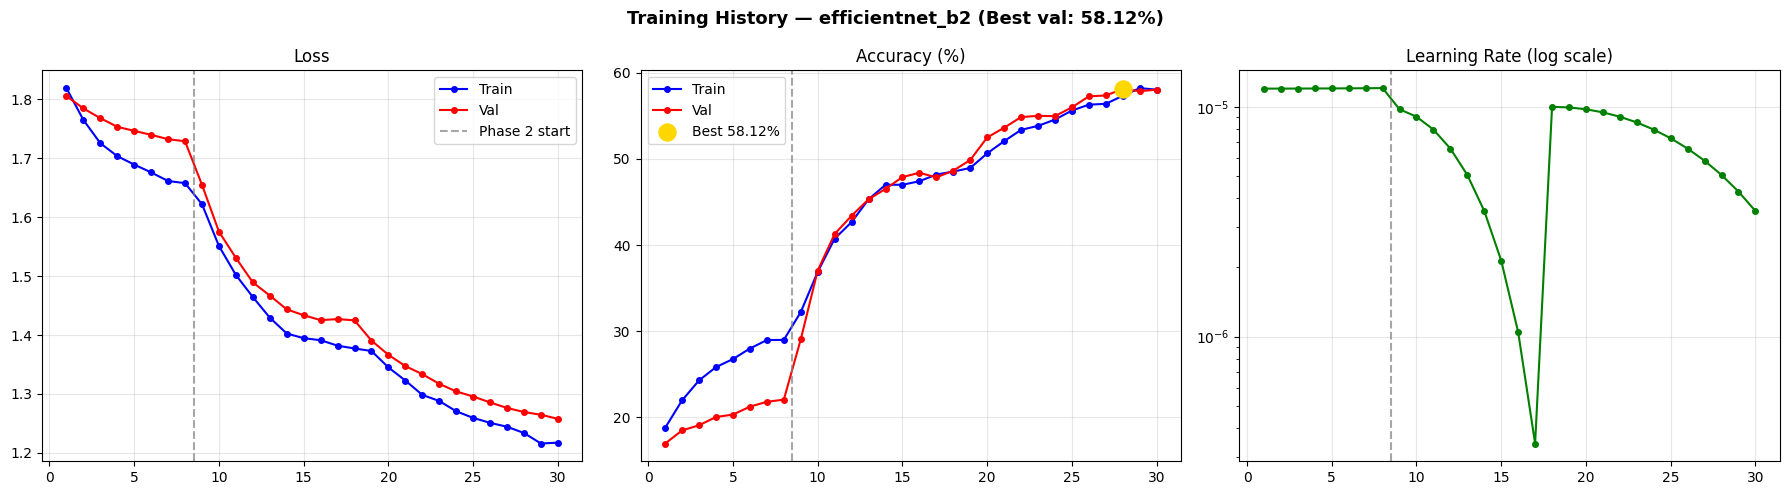

✅ Saved: /kaggle/working/plots/efficientnet_b2_history.png



TEST EVALUATION — efficientnet_b2
Accuracy      : 59.26%
F1 (macro)    : 0.5749
F1 (weighted) : 0.5930

              precision    recall  f1-score   support

       Angry       0.48      0.64      0.55       399
        Fear       0.42      0.39      0.40       410
       Happy       0.90      0.73      0.81       722
     Neutral       0.54      0.60      0.57       497
         Sad       0.50      0.38      0.43       483
    Surprise       0.61      0.79      0.69       317

    accuracy                           0.59      2828
   macro avg       0.58      0.59      0.57      2828
weighted avg       0.61      0.59      0.59      2828



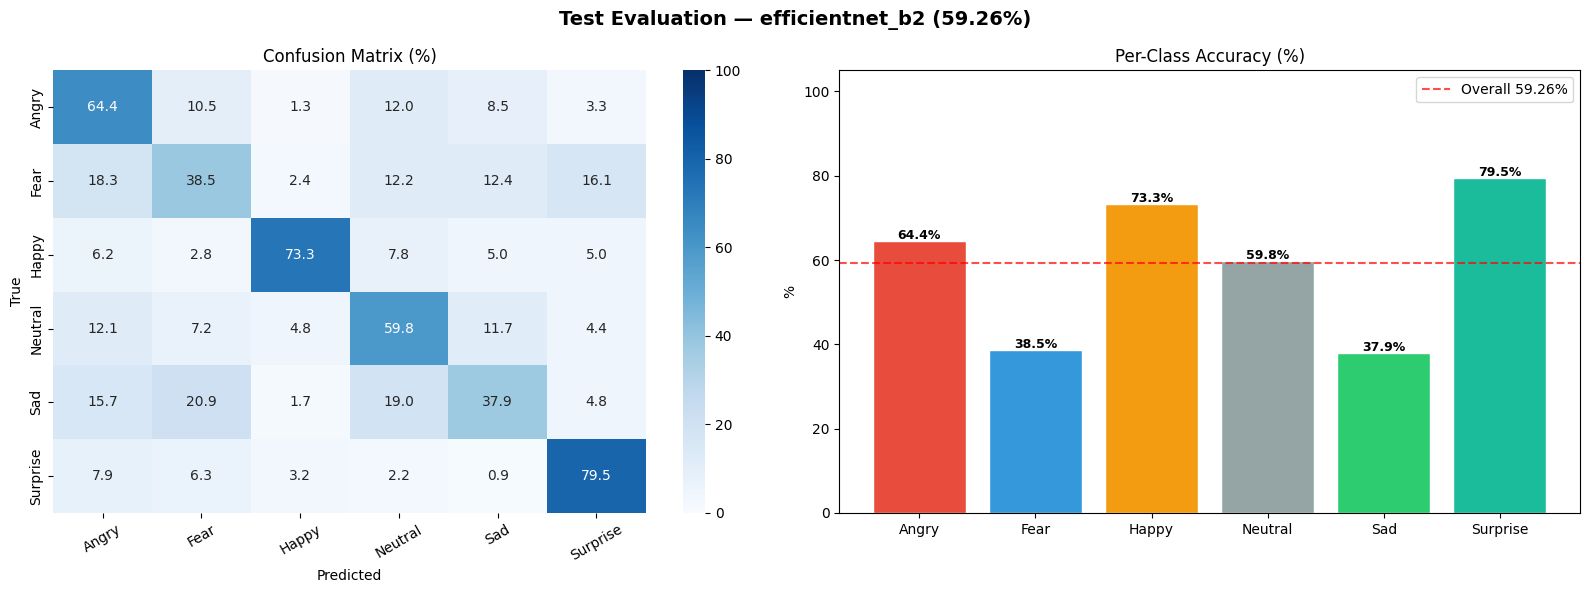

✅ Saved: /kaggle/working/plots/efficientnet_b2_evaluation.png


In [23]:
# ============================================================
# CELL 3.6 — TRAIN MODEL 1: EfficientNet-B2
# ============================================================
model_eff, history_eff, best_eff = train_model('efficientnet_b2')
plot_history(history_eff, 'efficientnet_b2', best_eff)
acc_eff, preds_eff, labels_eff = full_evaluation(model_eff, 'efficientnet_b2')


  Training: RESNET50

[Phase 1] WARM-UP — 8 epochs
🔒 ResNet stem+layer1-2 frozen | layer3-4 + head trainable


Ep  1/30 | Loss 9.0371/4.1954 | Acc 22.34%/29.93% | LR 1.20e-05 | 109.3s  ⭐ Best!


Ep  2/30 | Loss 6.6599/2.5935 | Acc 27.38%/39.23% | LR 1.20e-05 | 110.7s  ⭐ Best!


Ep  3/30 | Loss 4.2139/1.9482 | Acc 26.65%/34.56% | LR 1.20e-05 | 111.4s


Ep  4/30 | Loss 3.1603/2.9615 | Acc 26.25%/41.99% | LR 1.20e-05 | 109.9s  ⭐ Best!


...

Ep 26/30 | Loss 1.1559/2.1310 | Acc 63.22%/63.99% | LR 2.00e-06 | 109.0s  ⭐ Best!


Ep 27/30 | Loss 1.1446/1.7365 | Acc 63.49%/62.12% | LR 1.78e-06 | 111.1s


Ep 28/30 | Loss 1.1298/2.0923 | Acc 64.24%/64.13% | LR 1.55e-06 | 111.0s  ⭐ Best!


Ep 29/30 | Loss 1.1262/2.9554 | Acc 64.67%/64.24% | LR 1.32e-06 | 112.8s  ⭐ Best!


Ep 30/30 | Loss 1.1088/2.5304 | Acc 65.28%/64.24% | LR 1.10e-06 | 110.7s

✅ resnet50 done! Best val acc: 64.24%


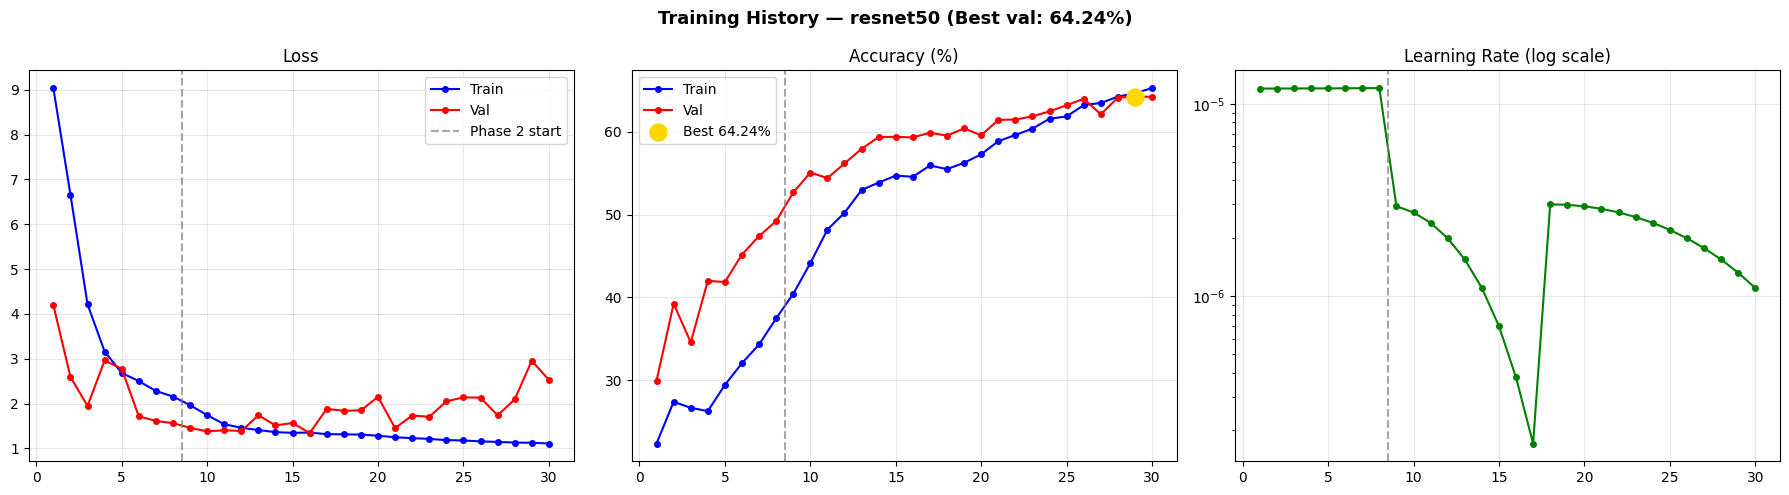

✅ Saved: /kaggle/working/plots/resnet50_history.png



TEST EVALUATION — resnet50
Accuracy      : 64.75%
F1 (macro)    : 0.6300
F1 (weighted) : 0.6486

              precision    recall  f1-score   support

       Angry       0.59      0.64      0.62       399
        Fear       0.50      0.41      0.45       410
       Happy       0.90      0.81      0.85       722
     Neutral       0.58      0.68      0.62       497
         Sad       0.52      0.53      0.52       483
    Surprise       0.71      0.72      0.72       317

    accuracy                           0.65      2828
   macro avg       0.63      0.63      0.63      2828
weighted avg       0.65      0.65      0.65      2828



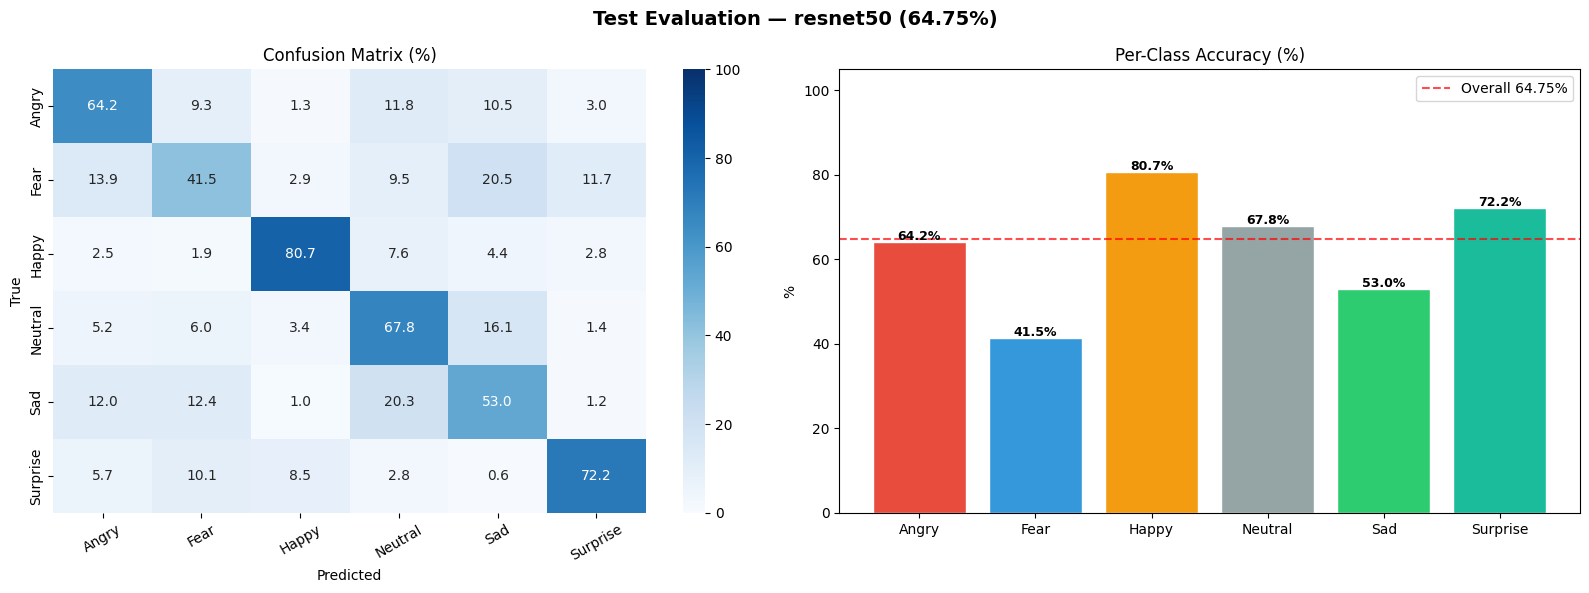

✅ Saved: /kaggle/working/plots/resnet50_evaluation.png


In [24]:
# ============================================================
# CELL 3.7 — TRAIN MODEL 2: ResNet-50
# ============================================================
model_res, history_res, best_res = train_model('resnet50')
plot_history(history_res, 'resnet50', best_res)
acc_res, preds_res, labels_res = full_evaluation(model_res, 'resnet50')


  Training: MOBILENET_V3

[Phase 1] WARM-UP — 8 epochs
🔒 MobileNet features[:-3] frozen | last 3 blocks + head trainable


Ep  1/30 | Loss 1.7666/1.7523 | Acc 22.49%/18.50% | LR 1.20e-05 | 113.1s  ⭐ Best!


Ep  2/30 | Loss 1.6559/1.6775 | Acc 28.61%/26.00% | LR 1.20e-05 | 99.9s  ⭐ Best!


Ep  3/30 | Loss 1.6052/1.6300 | Acc 32.26%/31.66% | LR 1.20e-05 | 101.4s  ⭐ Best!


Ep  4/30 | Loss 1.5688/1.5970 | Acc 34.97%/35.05% | LR 1.20e-05 | 100.0s  ⭐ Best!


...

Ep 26/30 | Loss 1.2419/1.3058 | Acc 56.70%/54.30% | LR 3.31e-06 | 104.4s


Ep 27/30 | Loss 1.2487/1.2892 | Acc 56.54%/56.53% | LR 2.93e-06 | 104.7s  ⭐ Best!


Ep 28/30 | Loss 1.2244/1.2884 | Acc 57.99%/56.60% | LR 2.55e-06 | 104.4s  ⭐ Best!


Ep 29/30 | Loss 1.2237/1.2827 | Acc 57.47%/55.89% | LR 2.17e-06 | 106.7s


Ep 30/30 | Loss 1.2242/1.2800 | Acc 57.59%/56.74% | LR 1.79e-06 | 107.4s  ⭐ Best!

✅ mobilenet_v3 done! Best val acc: 56.74%


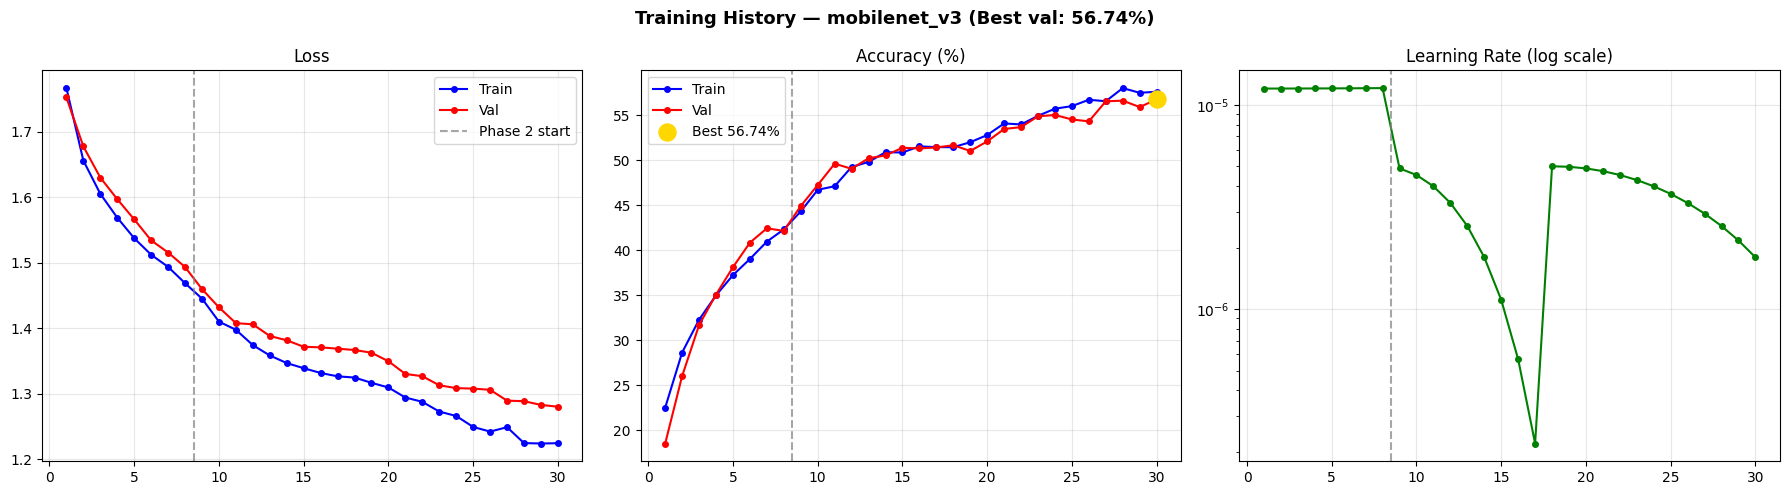

✅ Saved: /kaggle/working/plots/mobilenet_v3_history.png



TEST EVALUATION — mobilenet_v3
Accuracy      : 59.19%
F1 (macro)    : 0.5706
F1 (weighted) : 0.5910

              precision    recall  f1-score   support

       Angry       0.47      0.63      0.54       399
        Fear       0.44      0.34      0.38       410
       Happy       0.88      0.75      0.81       722
     Neutral       0.55      0.52      0.53       497
         Sad       0.51      0.47      0.49       483
    Surprise       0.57      0.80      0.67       317

    accuracy                           0.59      2828
   macro avg       0.57      0.59      0.57      2828
weighted avg       0.60      0.59      0.59      2828



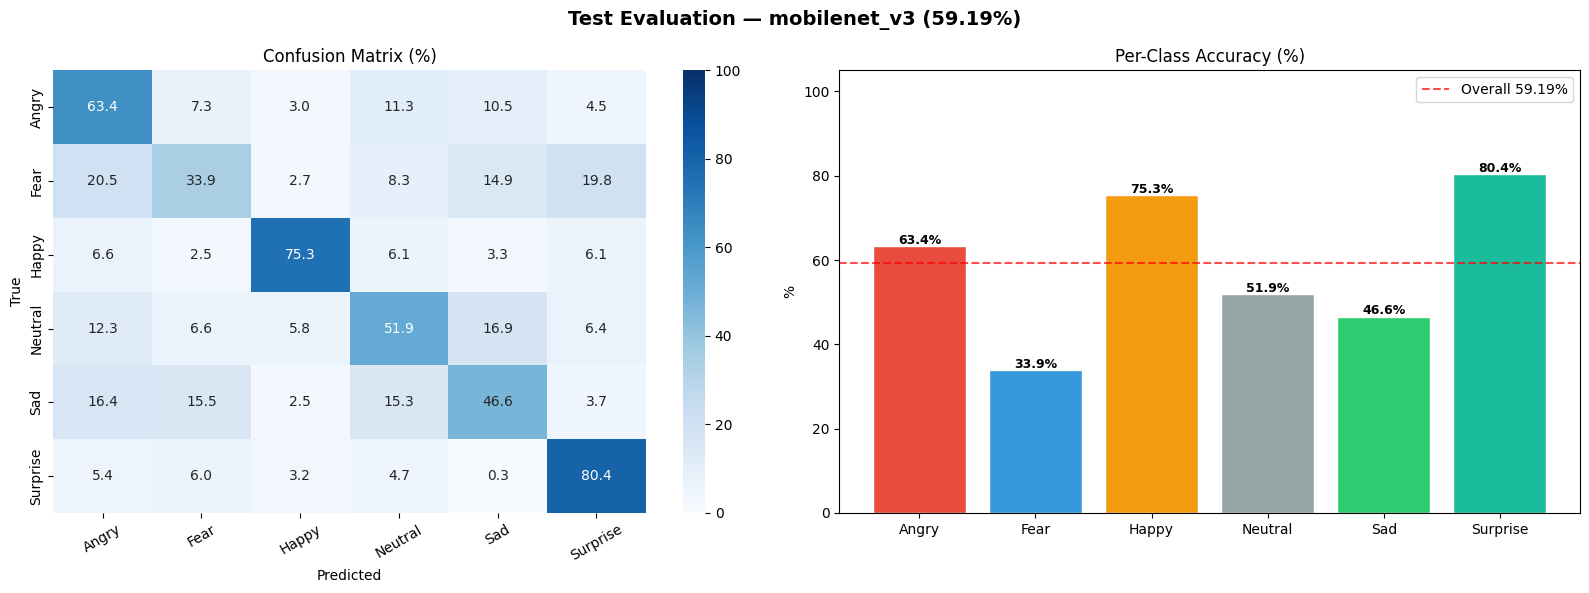

✅ Saved: /kaggle/working/plots/mobilenet_v3_evaluation.png


In [25]:
# ============================================================
# CELL 3.8 — TRAIN MODEL 3: MobileNetV3
# ============================================================
model_mob, history_mob, best_mob = train_model('mobilenet_v3')
plot_history(history_mob, 'mobilenet_v3', best_mob)
acc_mob, preds_mob, labels_mob = full_evaluation(model_mob, 'mobilenet_v3')

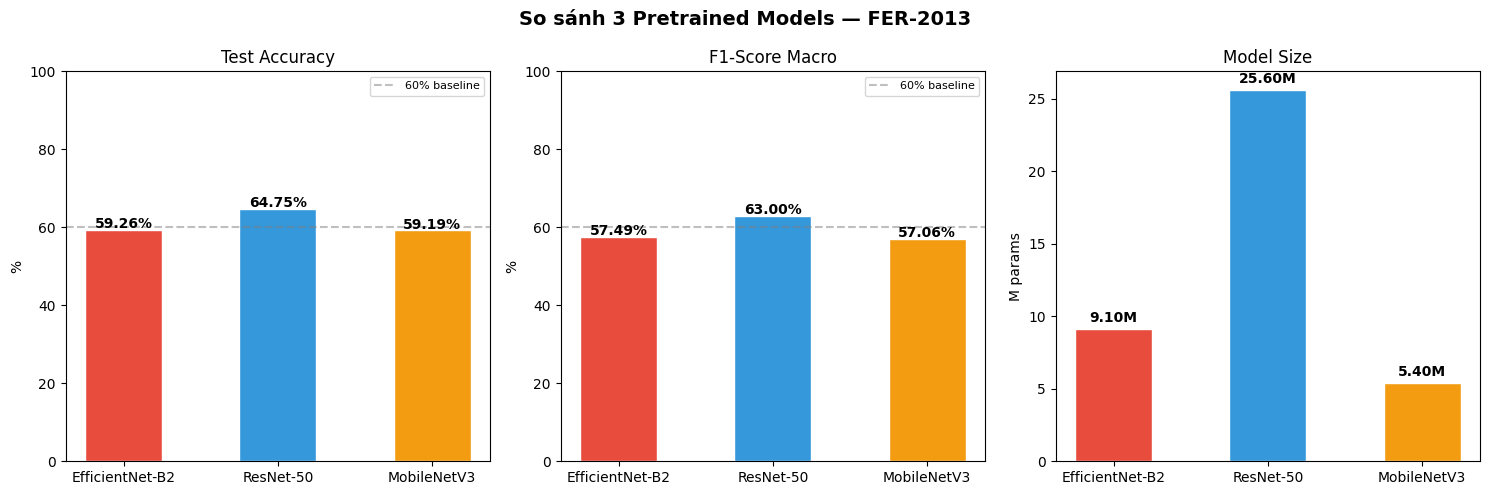


TỔNG KẾT
EfficientNet-B2     : Acc=59.26%  F1=0.5749  Params=9.1M
ResNet-50           : Acc=64.75%  F1=0.6300  Params=25.6M
MobileNetV3         : Acc=59.19%  F1=0.5706  Params=5.4M

🏆 Model tốt nhất: ResNet-50 (64.75%)

✅ HOÀN THÀNH TOÀN BỘ!


In [26]:
# ============================================================
# CELL 3.9 — SO SÁNH 3 MODEL
# ============================================================
results = {
    'EfficientNet-B2': {
        'acc': acc_eff,
        'f1':  f1_score(labels_eff, preds_eff, average='macro'),
        'params_M': 9.1
    },
    'ResNet-50': {
        'acc': acc_res,
        'f1':  f1_score(labels_res, preds_res, average='macro'),
        'params_M': 25.6
    },
    'MobileNetV3': {
        'acc': acc_mob,
        'f1':  f1_score(labels_mob, preds_mob, average='macro'),
        'params_M': 5.4
    }
}

names  = list(results.keys())
accs   = [results[n]['acc']*100 for n in names]
f1s    = [results[n]['f1']*100  for n in names]
params = [results[n]['params_M'] for n in names]
colors = ['#e74c3c', '#3498db', '#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('So sánh 3 Pretrained Models — FER-2013', fontsize=14, fontweight='bold')

for ax, vals, title, ylabel, suffix in zip(
    axes,
    [accs, f1s, params],
    ['Test Accuracy', 'F1-Score Macro', 'Model Size'],
    ['%', '%', 'M params'],
    ['%', '%', 'M']
):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12); ax.set_ylabel(ylabel)
    if suffix != 'M':
        ax.set_ylim(0, 100)
        ax.axhline(y=60, color='gray', ls='--', alpha=0.5, label='60% baseline')
        ax.legend(fontsize=8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{v:.2f}{suffix}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
save_path = f'{TrainCFG.PLOTS_DIR}/model_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('TỔNG KẾT')
print('='*60)
for name in names:
    r = results[name]
    print(f'{name:<20}: Acc={r["acc"]*100:.2f}%  F1={r["f1"]:.4f}  Params={r["params_M"]}M')
best_name = max(results, key=lambda n: results[n]['acc'])
print(f'\n🏆 Model tốt nhất: {best_name} ({results[best_name]["acc"]*100:.2f}%)')
print('\n✅ HOÀN THÀNH TOÀN BỘ!')

---
## PHẦN 4 — XUẤT MODEL CHO DEMO

In [27]:
# ============================================================
# CELL 4.1 — LƯU MODEL WEIGHTS (.pth) + CONFIG JSON
# ============================================================
import json as _json, shutil, zipfile

EXPORT_DIR = '/kaggle/working/fer_demo'
os.makedirs(EXPORT_DIR, exist_ok=True)

def export_model_for_demo(model, model_name, acc, f1):
    save_path = os.path.join(EXPORT_DIR, f'{model_name}.pth')
    torch.save({
        'model_name':       model_name,
        'model_state_dict': model.state_dict(),
        'num_classes':      CFG.NUM_CLASSES,
        'label_names':      CFG.LABEL_NAMES,
        'img_size':         CFG.IMG_SIZE,
        'mean':             CFG.MEAN,
        'std':              CFG.STD,
        'val_acc':          float(acc),
        'f1_macro':         float(f1),
    }, save_path)
    size_mb = os.path.getsize(save_path) / 1024 / 1024
    print(f'  ✅ {model_name}.pth — {size_mb:.1f} MB')

print('Xuất model weights...')
export_model_for_demo(model_eff, 'efficientnet_b2',
                      acc_eff, f1_score(labels_eff, preds_eff, average='macro'))
export_model_for_demo(model_res, 'resnet50',
                      acc_res, f1_score(labels_res, preds_res, average='macro'))
export_model_for_demo(model_mob, 'mobilenet_v3',
                      acc_mob, f1_score(labels_mob, preds_mob, average='macro'))

def cm_stats(labels, preds):
    cm = confusion_matrix(labels, preds)
    per_class = (cm.diagonal() / cm.sum(axis=1)).tolist()
    return cm.tolist(), per_class

cm_eff, pc_eff = cm_stats(labels_eff, preds_eff)
cm_res, pc_res = cm_stats(labels_res, preds_res)
cm_mob, pc_mob = cm_stats(labels_mob, preds_mob)

config = {
    'label_names': CFG.LABEL_NAMES,
    'num_classes': CFG.NUM_CLASSES,
    'img_size':    CFG.IMG_SIZE,
    'mean':        CFG.MEAN,
    'std':         CFG.STD,
    'models': {
        'efficientnet_b2': {
            'file': 'efficientnet_b2.pth',
            'display_name': 'EfficientNet-B2',
            'params_M': 9.1,
            'description': 'SOTA accuracy/params — model chinh',
            'acc':  float(acc_eff),
            'f1':   float(f1_score(labels_eff, preds_eff, average='macro')),
            'per_class_acc': pc_eff,
            'confusion_matrix': cm_eff,
        },
        'resnet50': {
            'file': 'resnet50.pth',
            'display_name': 'ResNet-50',
            'params_M': 25.6,
            'description': 'Baseline manh, de so sanh',
            'acc':  float(acc_res),
            'f1':   float(f1_score(labels_res, preds_res, average='macro')),
            'per_class_acc': pc_res,
            'confusion_matrix': cm_res,
        },
        'mobilenet_v3': {
            'file': 'mobilenet_v3.pth',
            'display_name': 'MobileNetV3',
            'params_M': 5.4,
            'description': 'Nhe nhat, toi uu real-time',
            'acc':  float(acc_mob),
            'f1':   float(f1_score(labels_mob, preds_mob, average='macro')),
            'per_class_acc': pc_mob,
            'confusion_matrix': cm_mob,
        },
    }
}

config_path = os.path.join(EXPORT_DIR, 'config.json')
with open(config_path, 'w') as f:
    _json.dump(config, f, indent=2)
print('\n✅ config.json saved')

for fname in os.listdir(TrainCFG.PLOTS_DIR):
    shutil.copy(os.path.join(TrainCFG.PLOTS_DIR, fname),
                os.path.join(EXPORT_DIR, fname))
print('✅ Plots copied')

print('\nNoi dung thu muc export:')
for fn in sorted(os.listdir(EXPORT_DIR)):
    sz = os.path.getsize(os.path.join(EXPORT_DIR, fn)) / 1024 / 1024
    print(f'  {fn:<40} {sz:.1f} MB')


Xuất model weights...
  ✅ efficientnet_b2.pth — 32.6 MB
  ✅ resnet50.pth — 94.0 MB
  ✅ mobilenet_v3.pth — 13.0 MB

✅ config.json saved
✅ Plots copied

Noi dung thu muc export:
  config.json                              0.0 MB
  efficientnet_b2.pth                      32.6 MB
  efficientnet_b2_evaluation.png           0.1 MB
  efficientnet_b2_history.png              0.1 MB
  mobilenet_v3.pth                         13.0 MB
  mobilenet_v3_evaluation.png              0.1 MB
  mobilenet_v3_history.png                 0.1 MB
  model_comparison.png                     0.1 MB
  resnet50.pth                             94.0 MB
  resnet50_evaluation.png                  0.1 MB
  resnet50_history.png                     0.1 MB


In [28]:
# ============================================================
# CELL 4.2 — ZIP & TẢI VỀ
# ============================================================
zip_path = '/kaggle/working/fer_demo_models.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(EXPORT_DIR):
        zf.write(os.path.join(EXPORT_DIR, fname), fname)

size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f'✅ fer_demo_models.zip — {size_mb:.1f} MB')
print(f'   Path: {zip_path}')
print('\nTai ve: Output tab → fer_demo_models.zip → Download')
print('Giai nen vao thu muc fer_demo/ cung cap voi index.html')


✅ fer_demo_models.zip — 130.1 MB
   Path: /kaggle/working/fer_demo_models.zip

Tai ve: Output tab → fer_demo_models.zip → Download
Giai nen vao thu muc fer_demo/ cung cap voi index.html
